# Real-World AI-Driven Analytics Solution Using Python
## Deliverable 1: Data Preprocessing and Initial Model Development

**Dataset:** Heart Disease (UCI – Cleveland)

**Team:** Manish Rao Joginipalli, Manoj Kumar Kadiyala, Sreyas Reddy Mallypally

**Course:** Real-World AI-Driven Analytics with Python

This notebook loads the UCI Heart Disease dataset, explores and cleans it, engineers features, and trains two baseline classifiers to predict whether a patient has heart disease.

## 1. Introduction & Problem Framing

Heart disease is one of the leading causes of death worldwide, and catching it early can save lives. For this project our team wanted to see if we could use patient health measurements (age, blood pressure, cholesterol, chest pain type, etc.) to predict whether someone is likely to have heart disease.

**Stakeholders:** hospitals, doctors, and patients who would benefit from an early-warning screening tool.

**Problem type:** this is a binary classification problem — the model predicts `1` (disease present) or `0` (no disease).

**Goal for Deliverable 1:** clean the data, understand it through EDA, and build an initial model we can improve on in later deliverables.

## Setup and Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
)

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
sns.set_palette('pastel')
plt.rcParams['figure.dpi'] = 100

## 2. Dataset Exploration & Preprocessing

We load the Cleveland Heart Disease data straight from the UCI repository so the notebook runs in Colab without any manual upload. The file has no header row, so we pass the column names ourselves and treat `?` as a missing value.

In [17]:
url = (
    'https://archive.ics.uci.edu/ml/'
    'machine-learning-databases/heart-disease/processed.cleveland.data'
)

columns = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
    'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'
]

df = pd.read_csv(url, names=columns, na_values='?')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


**Column meanings (short version):** `age`, `sex` (1=male, 0=female), `cp` chest pain type, `trestbps` resting blood pressure, `chol` cholesterol, `fbs` fasting blood sugar, `restecg` resting ECG, `thalach` max heart rate, `exang` exercise-induced angina, `oldpeak` ST depression, `slope`, `ca` number of major vessels, `thal`, and `num` the diagnosis (0 = no disease, 1-4 = disease).

In [3]:
print('Shape:', df.shape)
print('\nInfo:')
df.info()

Shape: (303, 14)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  num       303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


In [4]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


In [5]:
print('Missing values per column:')
print(df.isnull().sum())

print('\nDuplicate rows:', df.duplicated().sum())

Missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
num         0
dtype: int64

Duplicate rows: 0


### Target variable

The raw `num` column is 0-4. We convert it to a simple binary target: `0` means no disease and `1` means disease present (any value 1-4).

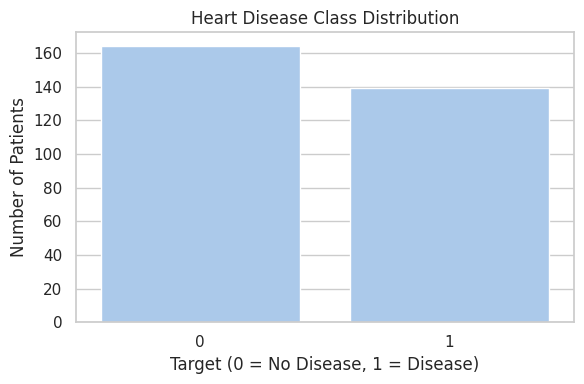

target
0    164
1    139
Name: count, dtype: int64


In [6]:
df['target'] = (df['num'] > 0).astype(int)
df = df.drop(columns='num')

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='target')
plt.title('Heart Disease Class Distribution')
plt.xlabel('Target (0 = No Disease, 1 = Disease)')
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.show()

print(df['target'].value_counts())

### Distributions of key numeric features

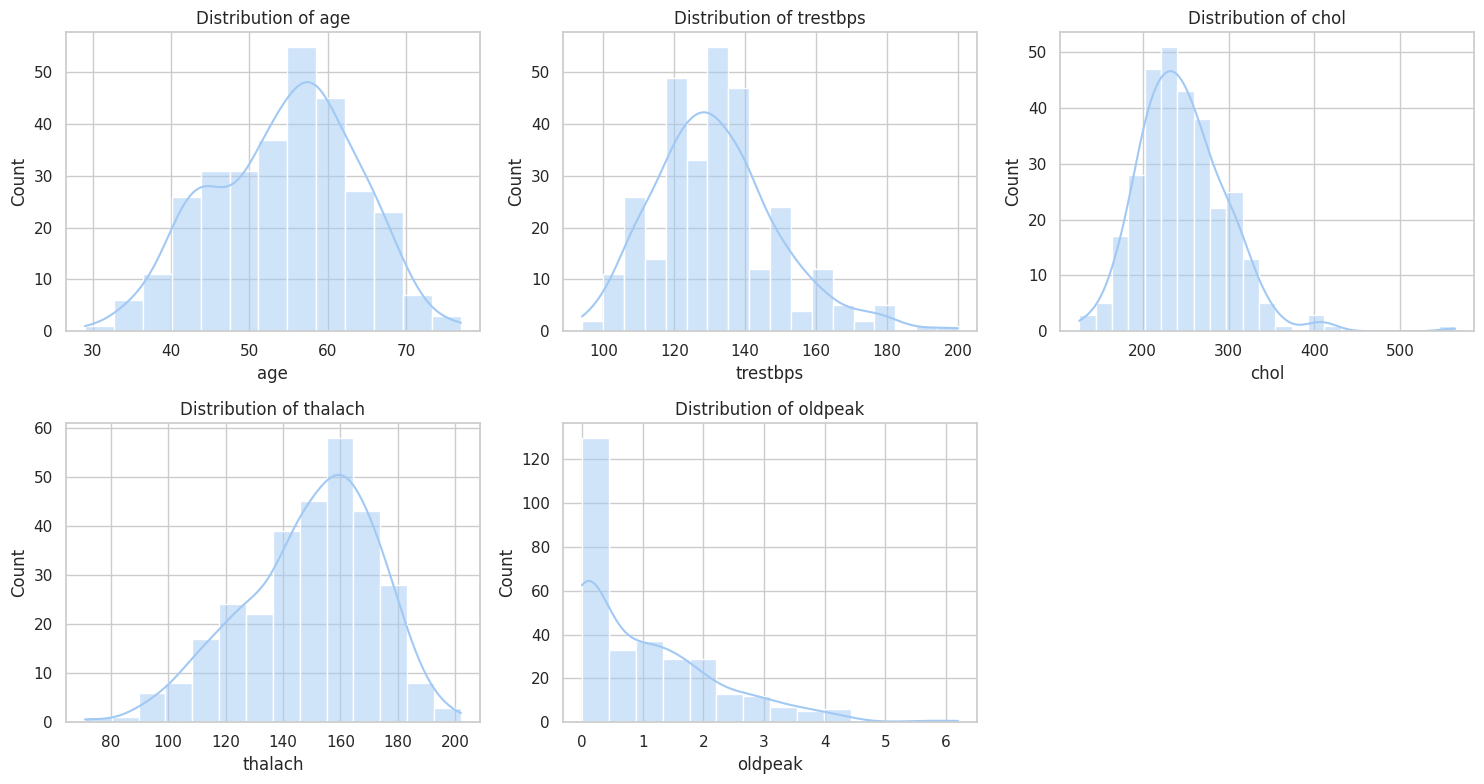

In [7]:
num_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(num_features):
    sns.histplot(data=df, x=col, kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
axes[-1].axis('off')  # hide the empty 6th panel
plt.tight_layout()
plt.show()

### Correlation heatmap

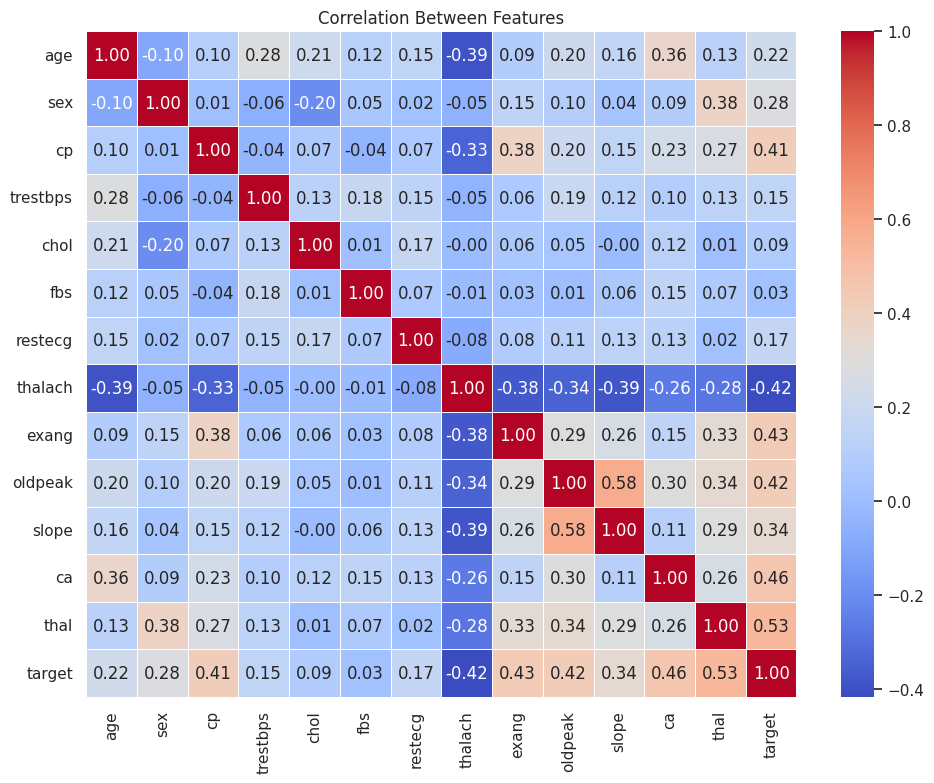

In [8]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Between Features')
plt.tight_layout()
plt.show()

### Cleaning

`ca` and `thal` have a few missing values. Because there are so few, we fill them with the column median instead of dropping rows. We also drop any duplicate rows.

In [9]:
df = df.drop_duplicates()

for col in ['ca', 'thal']:
    df[col] = df[col].fillna(df[col].median())

print('Missing values after cleaning:', df.isnull().sum().sum())
print('Shape after cleaning:', df.shape)

Missing values after cleaning: 0
Shape after cleaning: (303, 14)


### Feature engineering and scaling

A few columns (`cp`, `restecg`, `slope`, `thal`) are categorical codes rather than real numbers, so we one-hot encode them. Then we standardize all features so the logistic regression model treats them on a fair scale.

In [10]:
categorical = ['cp', 'restecg', 'slope', 'thal']
df_encoded = pd.get_dummies(df, columns=categorical, drop_first=True)

X = df_encoded.drop(columns='target')
y = df_encoded['target']

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
X_scaled.head()

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,ca,cp_2.0,cp_3.0,cp_4.0,restecg_1.0,restecg_2.0,slope_2.0,slope_3.0,thal_6.0,thal_7.0
0,0.948726,0.686202,0.757525,-0.264900,2.394438,0.017197,-0.696631,1.087338,-0.711131,-0.444554,-0.629534,-0.951662,-0.115663,1.023375,-0.926766,3.664502,3.979112,-0.793116
1,1.392002,0.686202,1.611220,0.760415,-0.417635,-1.821905,1.435481,0.397182,2.504881,-0.444554,-0.629534,1.050793,-0.115663,1.023375,1.079021,-0.272888,-0.251312,-0.793116
2,1.392002,0.686202,-0.665300,-0.342283,-0.417635,-0.902354,1.435481,1.346147,1.432877,-0.444554,-0.629534,1.050793,-0.115663,1.023375,1.079021,-0.272888,-0.251312,1.260850
3,-1.932564,0.686202,-0.096170,0.063974,-0.417635,1.637359,-0.696631,2.122573,-0.711131,-0.444554,1.588476,-0.951662,-0.115663,-0.977158,-0.926766,3.664502,-0.251312,-0.793116
4,-1.489288,-1.457296,-0.096170,-0.825922,-0.417635,0.980537,-0.696631,0.310912,-0.711131,2.249444,-0.629534,-0.951662,-0.115663,1.023375,-0.926766,-0.272888,-0.251312,-0.793116


### Train-test split

We hold out 25% of the data for testing and use `stratify=y` so both sets keep the same balance of disease vs. no-disease patients.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, random_state=42, stratify=y
)

print('Training samples:', X_train.shape[0])
print('Testing samples:', X_test.shape[0])

Training samples: 227
Testing samples: 76


## 3. Initial Model Development

We train two baseline models and compare them: a **Logistic Regression** (simple and interpretable) and a **Random Forest** (usually stronger, handles non-linear patterns).

In [12]:
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)
log_pred = logreg.predict(X_test)

print('Logistic Regression')
print('Accuracy:', round(accuracy_score(y_test, log_pred), 3))
print('ROC-AUC :', round(roc_auc_score(y_test, logreg.predict_proba(X_test)[:, 1]), 3))
print('\n', classification_report(y_test, log_pred))

Logistic Regression
Accuracy: 0.842
ROC-AUC : 0.927

               precision    recall  f1-score   support

           0       0.85      0.85      0.85        41
           1       0.83      0.83      0.83        35

    accuracy                           0.84        76
   macro avg       0.84      0.84      0.84        76
weighted avg       0.84      0.84      0.84        76



In [13]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print('Random Forest')
print('Accuracy:', round(accuracy_score(y_test, rf_pred), 3))
print('ROC-AUC :', round(roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1]), 3))
print('\n', classification_report(y_test, rf_pred))

Random Forest
Accuracy: 0.842
ROC-AUC : 0.94

               precision    recall  f1-score   support

           0       0.87      0.83      0.85        41
           1       0.81      0.86      0.83        35

    accuracy                           0.84        76
   macro avg       0.84      0.84      0.84        76
weighted avg       0.84      0.84      0.84        76



### Confusion matrices

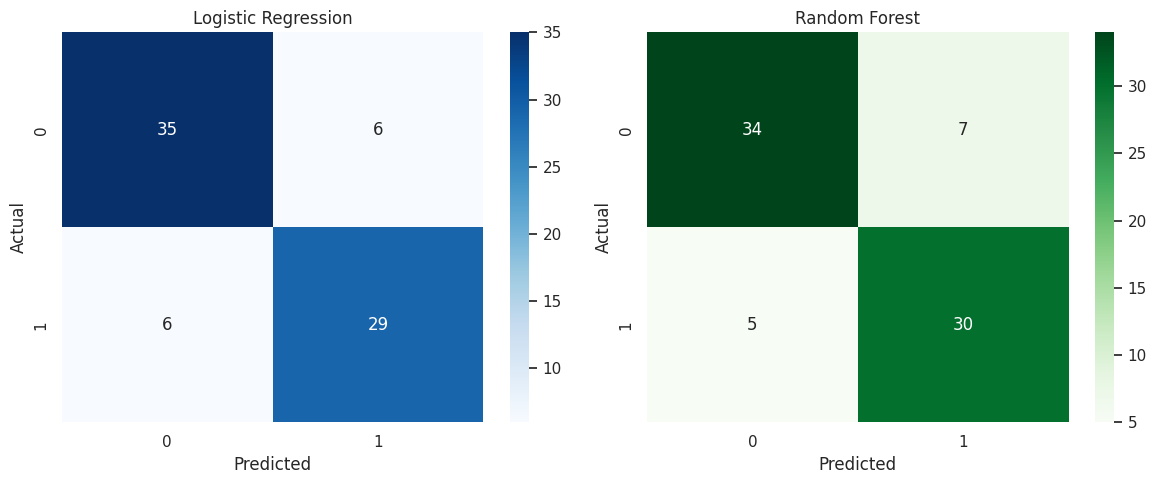

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(confusion_matrix(y_test, log_pred), annot=True, fmt='d',
            cmap='Blues', ax=axes[0])
axes[0].set_title('Logistic Regression')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt='d',
            cmap='Greens', ax=axes[1])
axes[1].set_title('Random Forest')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

### Hyperparameter tuning (Random Forest)

We run a small grid search to see if we can squeeze out a bit more performance from the Random Forest.

In [15]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid, cv=5, scoring='accuracy', n_jobs=-1
)
grid.fit(X_train, y_train)

print('Best parameters:', grid.best_params_)
print('Best CV accuracy:', round(grid.best_score_, 3))

best_pred = grid.best_estimator_.predict(X_test)
print('Tuned test accuracy:', round(accuracy_score(y_test, best_pred), 3))

Best parameters: {'max_depth': 5, 'n_estimators': 100}
Best CV accuracy: 0.819
Tuned test accuracy: 0.842


### Which features matter most?

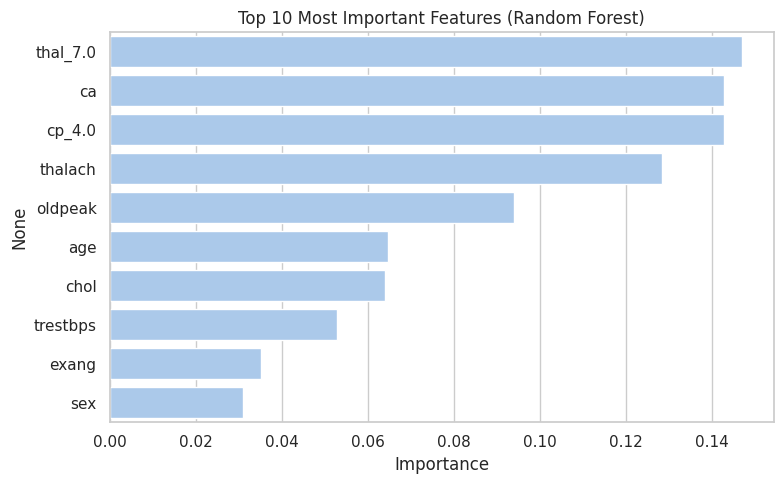

In [16]:
importances = pd.Series(
    grid.best_estimator_.feature_importances_, index=X_train.columns
).sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 5))
sns.barplot(x=importances.values, y=importances.index)
plt.title('Top 10 Most Important Features (Random Forest)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## Ethical Considerations

- **Bias in the data:** the Cleveland dataset is fairly small (~300 patients) and comes from one hospital, so it may not represent every population. A model trained on it could be less accurate for groups that are under-represented.
- **Demographic performance:** the data is skewed toward male patients, so the model might perform worse for female patients. In a real deployment we would check accuracy separately by sex and age group.
- **Transparency:** logistic regression is easy to explain, which matters a lot in healthcare where doctors need to understand why a prediction was made. Random forests are stronger but harder to interpret, so we keep both around.
- **Privacy:** patient health data is sensitive. Any real system would need to follow rules like HIPAA, anonymize records, and secure the data.
- **Human in the loop:** this tool should only support doctors, never replace a real diagnosis.

## 4. Team Collaboration Process

Our team worked in Google Colab and used GitHub for version control. We split the work so everyone owned a part of the pipeline:

- **Manish Rao Joginipalli** – data loading, cleaning, and missing-value handling
- **Manoj Kumar Kadiyala** – exploratory data analysis and visualizations
- **Sreyas Reddy Mallypally** – modeling, evaluation, and hyperparameter tuning

We met twice a week, kept a shared task list, and pushed our changes to a shared GitHub repo so we could review each other's code before merging.